## Abflow와 rmsd 측정 

example_ranges = {
    'h1': (25, 31), 'h2': (51, 56), 'h3': (98, 109),
    'l1': (144, 158), 'l2': (174, 180), 'l3': (213, 221)
}

cdr ranges를 input으로 넣을 때는 0-based python indexing (metadata에 존재하는 h1_start, ..., l3_end)

In [8]:
import numpy as np
from Bio.PDB import PDBParser, Superimposer
from typing import Dict, List, Tuple

def get_clean_residues(chain):
    """
    Water / HETATM 제외한 standard amino acid residue만 반환
    """
    return [res for res in chain if res.id[0] == " "]


def get_ca(residue):
    return residue["CA"] if "CA" in residue else None

def get_structure_data(structure):
    """
    첫 model 기준
    chain 0: Heavy
    chain 1: Light
    chain 2: Antigen
    """
    model = next(structure.get_models())
    chains = list(model.get_chains())

    if len(chains) < 3:
        raise ValueError("Structure must contain at least 3 chains (H, L, Ag)")

    h_res = get_clean_residues(chains[0])
    l_res = get_clean_residues(chains[1])
    ag_res = get_clean_residues(chains[2])

    ab_global = h_res + l_res
    all_atoms = list(model.get_atoms())

    return ab_global, ag_res, all_atoms


def extract_ab_atoms(
    global_residues: List,
    cdr_ranges_global: Dict[str, Tuple[int, int]],
):
    """
    global residue index 기준으로
    - Framework CA
    - CDR별 CA dict
    """
    total_len = len(global_residues)
    cdr_indices = set()

    cdr_atoms = {k: [] for k in cdr_ranges_global}
    fr_atoms = []

    for cdr, (start, end) in cdr_ranges_global.items():
        for i in range(start, end):
            if i < total_len:
                ca = get_ca(global_residues[i])
                if ca is not None:
                    cdr_atoms[cdr].append(ca)
                    cdr_indices.add(i)

    for i, res in enumerate(global_residues):
        if i not in cdr_indices:
            ca = get_ca(res)
            if ca is not None:
                fr_atoms.append(ca)

    return fr_atoms, cdr_atoms

def match_antigen_atoms(
    ag1: List,
    ag2: List,
):
    """
    Antigen residue 길이가 달라도
    (resseq, icode) 기준으로 공통 CA만 매칭
    """
    def res_key(res):
        return (res.id[1], res.id[2])  # resseq, icode

    ag1_map = {res_key(r): r for r in ag1 if "CA" in r}
    ag2_map = {res_key(r): r for r in ag2 if "CA" in r}

    common_keys = sorted(set(ag1_map) & set(ag2_map))

    atoms1 = [ag1_map[k]["CA"] for k in common_keys]
    atoms2 = [ag2_map[k]["CA"] for k in common_keys]

    return atoms1, atoms2

def calculate_rmsd(atoms1, atoms2):
    if len(atoms1) != len(atoms2) or len(atoms1) == 0:
        return None

    c1 = np.array([a.coord for a in atoms1])
    c2 = np.array([a.coord for a in atoms2])
    return np.sqrt(((c1 - c2) ** 2).sum() / len(atoms1))

def analyze_double_alignment(
    pdb1_path: str,
    pdb2_path: str,
    cdr_ranges_global: Dict[str, Tuple[int, int]],
):
    """
    Scenario 1:
      Align on Antigen (common residues) → measure Framework RMSD

    Scenario 2:
      Align on Antibody Framework → measure CDR RMSDs
    """
    output = {}
    parser = PDBParser(QUIET=True)

    print(f"\n=== Analyzing ===")
    print(pdb1_path)
    print(pdb2_path)

    # ------------------------
    # Load structures
    # ------------------------
    s1 = parser.get_structure("S1", pdb1_path)
    s2 = parser.get_structure("S2", pdb2_path)

    ab1, ag1, all_atoms1 = get_structure_data(s1)
    ab2, ag2, all_atoms2 = get_structure_data(s2)

    if len(ab1) != len(ab2):
        raise ValueError("Antibody residue count mismatch")

    # ------------------------
    # Atom extraction
    # ------------------------
    fr1, cdrs1 = extract_ab_atoms(ab1, cdr_ranges_global)
    fr2, cdrs2 = extract_ab_atoms(ab2, cdr_ranges_global)

    ag_atoms1, ag_atoms2 = match_antigen_atoms(ag1, ag2)

    if len(ag_atoms1) < 3:
        raise ValueError("Not enough common antigen residues for alignment")

    # =========================================================
    # Scenario 1: Antigen alignment → Framework RMSD
    # =========================================================
    sup_ag = Superimposer()
    sup_ag.set_atoms(ag_atoms1, ag_atoms2)
    sup_ag.apply(all_atoms2)

    output["fr_rms"] = calculate_rmsd(fr1, fr2)

    # =========================================================
    # Scenario 2: Framework alignment → CDR RMSDs
    # =========================================================
    sup_fr = Superimposer()
    sup_fr.set_atoms(fr1, fr2)
    sup_fr.apply(all_atoms2)

    for cdr in cdr_ranges_global:
        output[f"{cdr}_rms"] = calculate_rmsd(
            cdrs1.get(cdr, []),
            cdrs2.get(cdr, []),
        )

    return output


In [10]:
import os 
import pandas as pd 
import json 
import re

label_dir = '/home/psh/protein-frame-flow/inference_outputs/CDRFlow_v2.3.2.2_stage_2_ori_perturb_stage3/2025-12-06_22-56-57/epoch=52-step=75949_copy/5grj_high_var'
cdrflow_inf_dir = '/home/psh/protein-frame-flow/inference_outputs/CDRFlow_v2.3.2.2_stage_3_confidence_only_plddt/2025-12-12_09-21-35/epoch=27-step=40124/5grj_optimab_refine_high_plddt'
metadata_path = '/home/psh/BioBetter/5grj/meta_high_var/metadata.csv'

import re

def extract_mutation_id(filename):
    # 1. 고정된 앞부분 (Prefix)
    # 예: 5grj_H_L_A_WT__WT__
    prefix = r"[a-zA-Z0-9]+_[a-zA-Z0-9]+_[a-zA-Z0-9]+_[a-zA-Z0-9]+_WT__WT__"
    
    # 2. Mutation 부분 (반복 가능)
    # [A-Za-z]\d+[A-Za-z] : 기본 Mutation 단위 (예: A103Y)
    # (?:_[A-Za-z]\d+[A-Za-z])* : '_'로 시작하는 Mutation 단위가 0번 이상 반복됨
    mutation_pattern = r"[A-Za-z]\d+[A-Za-z](?:_[A-Za-z]\d+[A-Za-z])*"
    
    # 전체 패턴 합치기
    pattern = f"({prefix}{mutation_pattern})"   
    match = re.search(pattern, filename)
    return match.group(1)

# 데이터프레임 로드
df = pd.read_csv(metadata_path)

for filename in os.listdir(cdrflow_inf_dir):
    if '.pdb' not in filename:
        continue
    
    pdb_path = os.path.join(cdrflow_inf_dir, filename)
    mutation_id = extract_mutation_id(filename)
    label_sub_dir = os.path.join(label_dir, mutation_id, "optimab_input")
    label_pdb_path = next(
        os.path.join(label_sub_dir, f)
        for f in os.listdir(label_sub_dir)
        if f.endswith('upper.pdb')
    )

    # DataFrame 필터링
    filtered_row = df.head(1)
    write_path = pdb_path.replace('.pdb', '_rmsd.json')

    cdr_ranges = {}
    for cdr_type in ['h1', 'h2', 'h3', 'l1', 'l2', 'l3']:
        # [수정] .iloc[0]을 사용하여 값(Value)만 추출하고 int로 변환
        start_val = int(filtered_row[f"{cdr_type}_start"].iloc[0])
        end_val = int(filtered_row[f"{cdr_type}_end"].iloc[0])
        
        cdr_ranges[cdr_type] = (start_val, end_val)
        
    # 분석 함수 실행
    output = analyze_double_alignment(label_pdb_path, pdb_path, cdr_ranges)
    output['mutation_id'] = mutation_id
    with open(write_path, 'w') as f:
        json.dump(output, f, indent=4)   # 가독성 좋게 indent 추가



=== Analyzing ===
/home/psh/protein-frame-flow/inference_outputs/CDRFlow_v2.3.2.2_stage_2_ori_perturb_stage3/2025-12-06_22-56-57/epoch=52-step=75949_copy/5grj_high_var/5grj_H_L_A_WT__WT__K100R_G102S/optimab_input/sample_0_upper.pdb
/home/psh/protein-frame-flow/inference_outputs/CDRFlow_v2.3.2.2_stage_3_confidence_only_plddt/2025-12-12_09-21-35/epoch=27-step=40124/5grj_optimab_refine_high_plddt/meta_high_var_5grj_H_L_A_WT__WT__K100R_G102S_sample_0_upper_id_702_sample_2.pdb

=== Analyzing ===
/home/psh/protein-frame-flow/inference_outputs/CDRFlow_v2.3.2.2_stage_2_ori_perturb_stage3/2025-12-06_22-56-57/epoch=52-step=75949_copy/5grj_high_var/5grj_H_L_A_WT__WT__K100R_G102S/optimab_input/sample_0_upper.pdb
/home/psh/protein-frame-flow/inference_outputs/CDRFlow_v2.3.2.2_stage_3_confidence_only_plddt/2025-12-12_09-21-35/epoch=27-step=40124/5grj_optimab_refine_high_plddt/meta_high_var_5grj_H_L_A_WT__WT__K100R_G102S_sample_0_upper_id_528_sample_5.pdb

=== Analyzing ===
/home/psh/protein-frame-f

## frame RMSD 및 H3 CDR RMSD 시각화 

/home/psh/mambaforge/envs/fm/lib/python3.10/site-packages/seaborn/categorical.py:166: FutureWarning: Setting a gradient palette using color= is deprecated and will be removed in version 0.13. Set `palette='dark:black'` for same effect.
  warnings.warn(msg, FutureWarning)


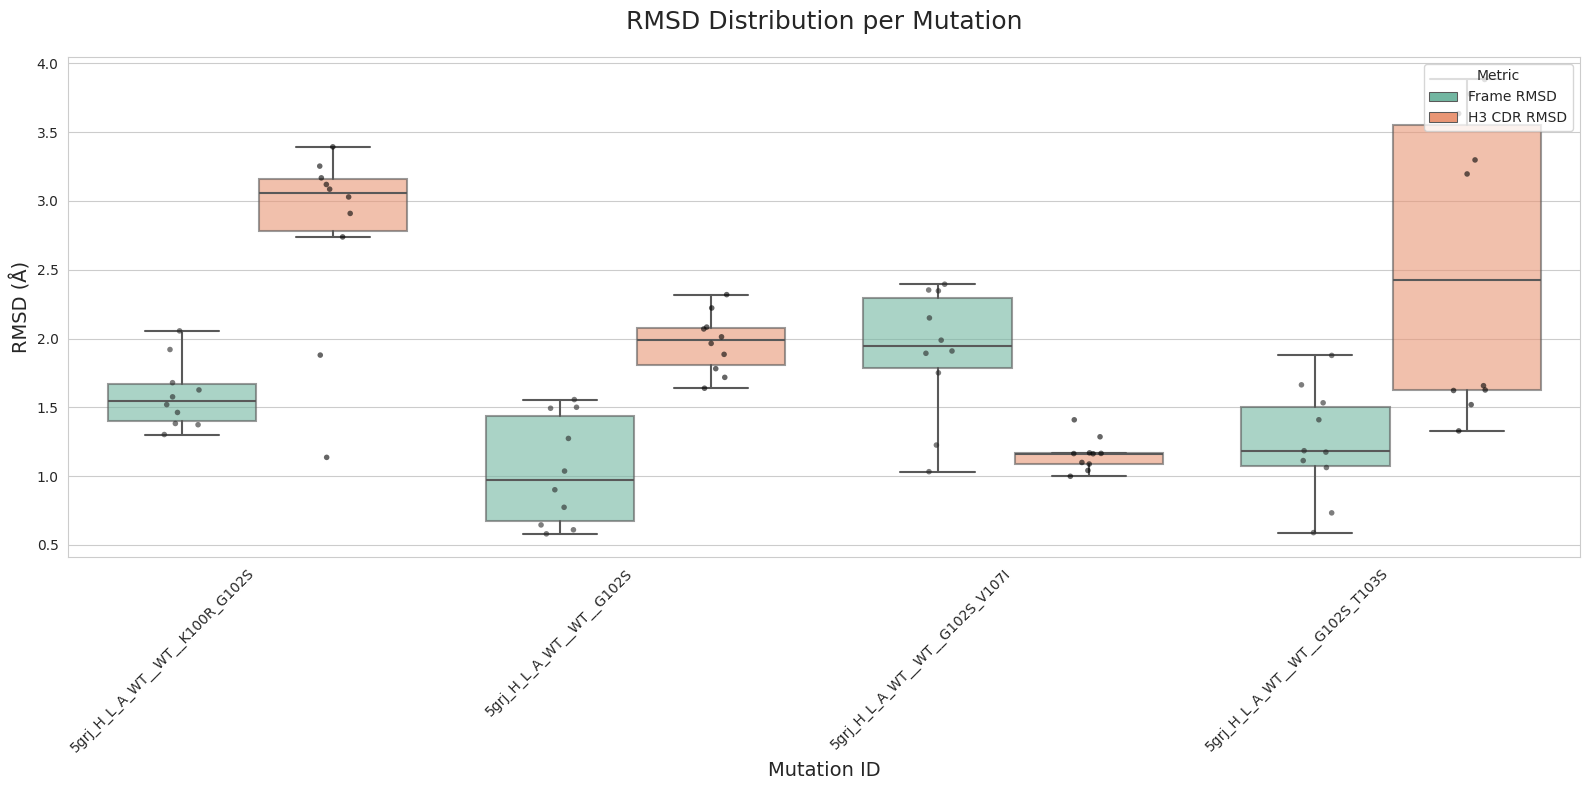

Total data points plotted: 40


In [13]:
import os
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 데이터 디렉토리 설정
data_dir = '/home/psh/protein-frame-flow/inference_outputs/CDRFlow_v2.3.2.2_stage_3_confidence_only_plddt/2025-12-12_09-21-35/epoch=27-step=40124/5grj_optimab_refine_high_plddt'

# 2. 데이터 수집
data_list = []

if os.path.exists(data_dir):
    for filename in os.listdir(data_dir):
        if filename.endswith('_rmsd.json'):
            filepath = os.path.join(data_dir, filename)
            with open(filepath, 'r') as f:
                try:
                    content = json.load(f)
                    mutation_id = content.get('mutation_id', filename.replace('_rmsd.json', ''))
                    
                    data_list.append({
                        'Mutation ID': mutation_id,
                        'Frame RMSD': content.get('fr_rms', 0.0),
                        'H3 CDR RMSD': content.get('h3_rms', 0.0)
                    })
                except json.JSONDecodeError:
                    continue

# 3. 데이터프레임 생성 및 변환
df = pd.DataFrame(data_list)

if not df.empty:
    # Long Format으로 변환 (seaborn 호환용)
    df_melted = df.melt(
        id_vars=['Mutation ID'], 
        value_vars=['Frame RMSD', 'H3 CDR RMSD'],
        var_name='RMSD Type', 
        value_name='RMSD (Å)'
    )
    
    # 4. 시각화 (Boxplot + Stripplot)
    plt.figure(figsize=(16, 8))
    sns.set_style("whitegrid")

    # (1) Boxplot 그리기
    # showfliers=False: 이상치(outlier) 점을 여기서 그리지 않음 (아래 stripplot이 모든 점을 그리기 때문)
    ax = sns.boxplot(
        data=df_melted,
        x='Mutation ID',
        y='RMSD (Å)',
        hue='RMSD Type',
        palette="Set2",
        showfliers=False,  
        boxprops={'alpha': 0.6} # 박스를 약간 투명하게 해서 점이 잘 보이도록 함
    )

    # (2) Stripplot (점) 그리기
    # dodge=True: Boxplot 처럼 Hue(색상)에 따라 점들을 분리해서 배치
    sns.stripplot(
        data=df_melted,
        x='Mutation ID',
        y='RMSD (Å)',
        hue='RMSD Type',
        dodge=True,      # 중요: 박스 위치에 맞춰 점 이동
        jitter=True,     # 점들이 겹치지 않게 좌우로 흩뿌림
        color='black',   # 점 색상은 검정(혹은 짙은 회색)으로 통일
        alpha=0.6,       # 점 투명도
        size=4,          # 점 크기
        legend=False     # 점에 대한 범례는 중복되므로 끔
    )

    # 그래프 꾸미기
    plt.title('RMSD Distribution per Mutation', fontsize=18, pad=20)
    plt.xticks(rotation=45, ha='right', fontsize=10)
    plt.ylabel('RMSD (Å)', fontsize=14)
    plt.xlabel('Mutation ID', fontsize=14)
    
    # 범례 설정 (Boxplot의 범례만 유지)
    handles, labels = ax.get_legend_handles_labels()
    # handles[0:2]만 사용하여 Frame/H3 박스에 대한 범례만 표시 (점 범례 제외)
    plt.legend(handles[0:2], labels[0:2], title='Metric', loc='upper right')

    plt.tight_layout()
    plt.show()

    print(f"Total data points plotted: {len(df)}")
else:
    print("No data found.")

## CA만 존재하는 trans vector에 대해 frame rmsd 측정 

In [ ]:
import numpy as np
from Bio.PDB import PDBParser, Superimposer
from typing import List

def get_clean_residues(chain):
    # HETATM이 아닌 표준 잔기만 추출
    return [res for res in chain if res.id[0] == " "]

def get_ca(residue):
    return residue["CA"] if "CA" in residue else None

def get_structure_data(structure):
    """
    chain 0: Heavy
    chain 1: Light
    chain >=2: Antigen (all merged)
    """
    model = next(structure.get_models())
    chains = list(model.get_chains())

    if len(chains) < 3:
        raise ValueError("Need at least 3 chains (H, L, Ag)")

    h_res = get_clean_residues(chains[0])
    l_res = get_clean_residues(chains[1])

    ag_res = []
    for ch in chains[2:]:
        ag_res.extend(get_clean_residues(ch))

    # Antibody 전체 잔기 (H + L 순서 유지)
    ab_global = h_res + l_res
    
    # Superimposer 적용을 위해 모델 내 전체 원소 리스트 확보
    all_atoms = list(model.get_atoms())

    return ab_global, ag_res, all_atoms

def extract_framework_atoms(
    global_residues: List,
    cdr_ranges_global: dict,
):
    """
    global_residues 리스트 인덱스 기준으로 CDR 영역을 제외한 Framework CA 원자 추출
    """
    total_len = len(global_residues)
    cdr_indices = set()

    for _, (start, end) in cdr_ranges_global.items():
        # range(start, end) -> start 포함, end 미포함
        for i in range(start, end):
            if i < total_len:
                cdr_indices.add(i)

    fr_atoms = []
    for i, res in enumerate(global_residues):
        if i not in cdr_indices:
            ca = get_ca(res)
            if ca is not None:
                fr_atoms.append(ca)

    return fr_atoms

def match_antigen_atoms(ag1, ag2, verbose=False):
    """
    Antigen CA matching
    - Chain ID는 무시하고 (이미 chains[2:]로 필터링 했으므로),
    - Residue Number(id[1]) + Insertion Code(id[2])를 기준으로 매칭합니다.
    """
    def key(res):
        # 수정됨: Chain ID (res.get_parent().id) 제거
        # 오직 잔기 번호와 insertion code로만 매칭
        return (res.id[1], res.id[2])

    # 1. Key-Value 맵 생성
    ag1_map = {key(r): r["CA"] for r in ag1 if "CA" in r}
    ag2_map = {key(r): r["CA"] for r in ag2 if "CA" in r}

    # 2. 공통된 Key 찾기
    common_keys = sorted(set(ag1_map) & set(ag2_map))
    
    # [디버깅용] 만약 공통된 것이 하나도 없다면 정보를 출력
    if len(common_keys) == 0 and verbose:
        print(">>> Debugging Match Failure <<<")
        if ag1_map:
            print(f"Ref PDB Antigen Keys (First 5): {list(ag1_map.keys())[:5]}")
        else:
            print("Ref PDB has no CA in antigen chains.")
            
        if ag2_map:
            print(f"Mov PDB Antigen Keys (First 5): {list(ag2_map.keys())[:5]}")
        else:
            print("Mov PDB has no CA in antigen chains.")

    atoms1 = [ag1_map[k] for k in common_keys]
    atoms2 = [ag2_map[k] for k in common_keys]

    return atoms1, atoms2

def calculate_rmsd(atoms1, atoms2):
    if len(atoms1) != len(atoms2) or len(atoms1) == 0:
        print(f"Warning: Atom count mismatch or empty ({len(atoms1)} vs {len(atoms2)})")
        return None

    c1 = np.array([a.coord for a in atoms1])
    c2 = np.array([a.coord for a in atoms2])
    
    # Root Mean Square Deviation
    diff = c1 - c2
    return np.sqrt((diff ** 2).sum() / len(atoms1))

def analyze_antigen_alignment_framework_rmsd(
    pdb_ref: str,
    pdb_mov: str,
    cdr_ranges_global: dict,
):
    """
    1. Antigen 기준으로 Superimposition (Moving -> Ref)
    2. Antibody Framework 영역의 RMSD 계산
    """
    parser = PDBParser(QUIET=True)

    s1 = parser.get_structure("REF", pdb_ref)
    s2 = parser.get_structure("MOV", pdb_mov)

    ab1, ag1, all_atoms1 = get_structure_data(s1)
    ab2, ag2, all_atoms2 = get_structure_data(s2)

    # 기본 검증
    if len(ab1) != len(ab2):
        print(f"Warning: Antibody residue count mismatch ({len(ab1)} vs {len(ab2)}). RMSD might be inaccurate.")

    # 1. Antigen CA matching & Alignment
    ag_atoms1, ag_atoms2 = match_antigen_atoms(ag1, ag2)

    if len(ag_atoms1) < 3:
        raise ValueError(f"Not enough common antigen CA atoms: {len(ag_atoms1)}")

    sup = Superimposer()
    # set_atoms(fixed, moving) -> moving을 fixed로 맞추는 행렬 계산
    sup.set_atoms(ag_atoms1, ag_atoms2)
    
    # [수정 중요] 계산된 행렬을 Moving Structure (s2)의 전체 원자에 적용해야 함
    # s2의 좌표가 변환되면, s2에서 추출했던 fr2, ag2 등의 좌표도 자동으로 업데이트됨 (Reference 참조)
    sup.apply(all_atoms2) 

    # 2. Framework RMSD Calculation
    # 좌표 변환이 완료된 후 Framework 원자를 추출하거나, 미리 추출해둔 객체를 사용해도 됨 (좌표는 공유됨)
    fr1 = extract_framework_atoms(ab1, cdr_ranges_global)
    fr2 = extract_framework_atoms(ab2, cdr_ranges_global)

    rms_val = calculate_rmsd(fr1, fr2)

    return {
        "fr_rms": rms_val,
        "n_align_atoms": len(ag_atoms1),
        "n_fr_atoms": len(fr1) if fr1 else 0
    }

In [ ]:
import os 
import pandas as pd 
import json 

label_dir = '/home/psh/benchmark_after210930/pdb'
cdrflow_inf_dir = '/home/psh/protein-frame-flow/inference_outputs/CDRFlow_v2.3.2.1_stage_2_ori_perturb_stage3/2025-12-06_22-56-57/epoch=52-step=75949_copy/run_2025-12-15_13-58-38'
metadata_path = '/home/psh/benchmark_after210930/meta/metadata.csv'

# 데이터프레임 로드
df = pd.read_csv(metadata_path)

for pdb_id in os.listdir(label_dir):
    if '.pdb' not in pdb_id:
        continue
    
    pdb_path = os.path.join(cdrflow_inf_dir, pdb_id.replace('.pdb', ''))
    label_sample = os.path.join(label_dir, pdb_id)
    # # 파일명에서 sample_id 추출 로직 (파일명 포맷에 따라 확인 필요)
    # sample_id = '_'.join(file_id.split('_')[3:5])
    # abflow_sample = os.path.join(abflow_dir, sample_id + ".pdb")
    
    # DataFrame 필터링
    filtered_row = df[df['pdb_name'] == pdb_id.replace('.pdb', '')]

    cdrflow_sample = os.path.join(pdb_path, 'sample_0_perturbed_trans.pdb')
    write_path = os.path.join(pdb_path, 'rmsd_info_0_perturbed.json')

    cdr_ranges = {}
    for cdr_type in ['h1', 'h2', 'h3', 'l1', 'l2', 'l3']:
        # [수정] .iloc[0]을 사용하여 값(Value)만 추출하고 int로 변환
        start_val = int(filtered_row[f"{cdr_type}_start"].iloc[0])
        end_val = int(filtered_row[f"{cdr_type}_end"].iloc[0])
        
        cdr_ranges[cdr_type] = (start_val, end_val)
        
    # 분석 함수 실행
    output = analyze_antigen_alignment_framework_rmsd(label_sample, cdrflow_sample, cdr_ranges)
    
    with open(write_path, 'w') as f:
        json.dump(output, f, indent=4)   # 가독성 좋게 indent 추가


## perturbed trans rmsd & predicted frame rmsd visualization 

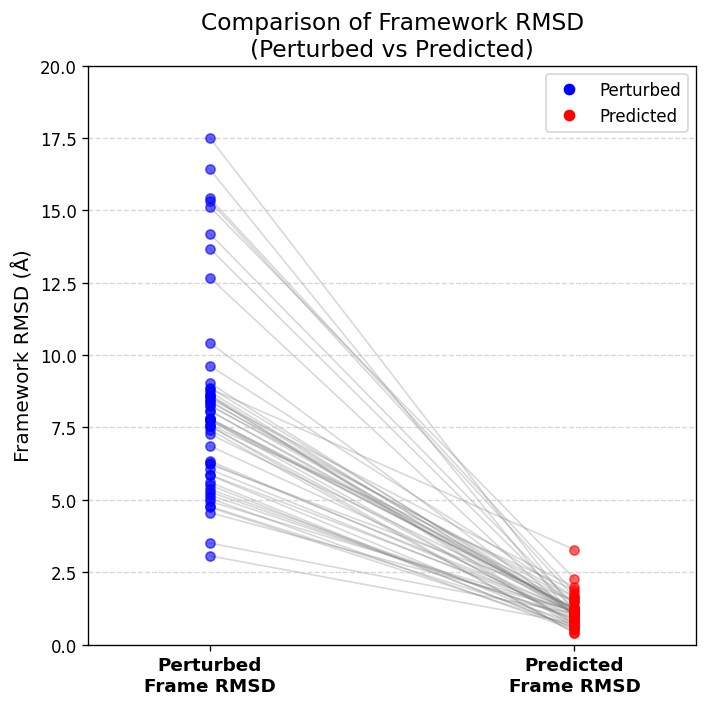

In [34]:
import os
import json
import matplotlib.pyplot as plt
import numpy as np

# 경로 설정
cdrflow_inf_dir = '/home/psh/protein-frame-flow/inference_outputs/CDRFlow_v2.3.2.1_stage_2_ori_perturb_stage3/2025-12-06_22-56-57/epoch=52-step=75949_copy/run_2025-12-15_13-58-38'

pred_fr_rmsd = []
perturbed_fr_rmsd = []

# --- [수정됨] 데이터 로딩 파트 ---
for pdb_id in os.listdir(cdrflow_inf_dir):
    if 'config' in pdb_id:
        continue
    
    # 디렉토리인지 확인 (안전을 위해)
    pdb_dir = os.path.join(cdrflow_inf_dir, pdb_id)
    if not os.path.isdir(pdb_dir):
        continue
    
    pred_json_path = os.path.join(pdb_dir, "rmsd_info_0.json")
    perturbed_json_path = os.path.join(pdb_dir, "rmsd_info_0_perturbed.json")

    # 파일이 실제로 존재하는지 확인
    if os.path.exists(pred_json_path) and os.path.exists(perturbed_json_path):
        # 2. Perturbation 결과 로드 (이 부분을 수정했습니다)
        with open(perturbed_json_path, 'r') as f:
            data = json.load(f)
            if data['fr_rms'] > 20: 
                continue
            perturbed_fr_rmsd.append(data['fr_rms'])

        # 1. Prediction 결과 로드
        with open(pred_json_path, 'r') as f:
            data = json.load(f)
            pred_fr_rmsd.append(data['fr_rms'])
            


# --- 시각화 파트 ---

# 캔버스 설정
plt.figure(figsize=(6, 6), dpi=120)

# X축 좌표 설정 (0: Perturbed, 1: Predicted)
x_coords = [0.2, 0.8]
labels = ['Perturbed\nFrame RMSD', 'Predicted\nFrame RMSD']

# 데이터 그리기
# zip을 사용하여 같은 인덱스의 데이터끼리 묶어서 처리
for p_rms, pred_rms in zip(perturbed_fr_rmsd, pred_fr_rmsd):
    y_coords = [p_rms, pred_rms]
    
    # 1. 선 그리기 (순서가 동일한 애들끼리 연결)
    # alpha 값을 낮춰서 선이 많아도 겹쳐 보일 수 있게 함
    plt.plot(x_coords, y_coords, color='gray', alpha=0.3, linewidth=1, zorder=1)
    
    # 2. 점 찍기 (양 끝점)
    # Perturbed는 파란색, Predicted는 빨간색 등으로 구분 가능
    plt.scatter(x_coords[0], y_coords[0], color='blue', s=30, zorder=2, alpha=0.6)
    plt.scatter(x_coords[1], y_coords[1], color='red', s=30, zorder=2, alpha=0.6)


# 그래프 꾸미기
plt.xticks(x_coords, labels, fontsize=11, fontweight='bold')
plt.ylabel('Framework RMSD (Å)', fontsize=12)
plt.ylim((0, 20))
plt.xlim((0,1))
plt.title('Comparison of Framework RMSD\n(Perturbed vs Predicted)', fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.5)

# 범례 추가 (점 색깔에 대한 설명)
from matplotlib.lines import Line2D
custom_lines = [Line2D([0], [0], color='blue', marker='o', linestyle=''),
                Line2D([0], [0], color='red', marker='o', linestyle='')]
plt.legend(custom_lines, ['Perturbed', 'Predicted'], loc='upper right')

# 여백 조정 및 출력
plt.tight_layout()
plt.show()
